Cameron Ela, cameronela13@gmail.com

# Image Classification with Transfer Learning

This notebook applies transfer learning to classify infrastructure and nature images from the [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) dataset into six categories: buildings, forest, glacier, mountain, sea, and street.

Four pre-trained convolutional architectures are evaluated (ResNet50, ResNet101, EfficientNetB0, and VGG16), each with frozen weights from ImageNet base and a custom classification softmax layer. Training data is split 80/20 into train and validation subsets. All models are trained with `batch_size=32`, up to 100 epochs, and early stopping (`patience=10`) on validation loss.

**VGG16** achieved the strongest performance across training, validation, and test sets. **EfficientNetB0** was the weakest performer and is not well-suited to this task: the architecture is designed for specific input aspect ratios and resolutions, so resizing images to 128×128 degrades its representational capacity relative to the other models.

In [72]:
# import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ssl
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
)

from IPython.display import display as ipy_display


# Environment Settings
Control device settings for downloading model weights and processing power.

In [53]:
# set number of threads for parallel processing (must be applied before TF is imported)
num_cores = 4
os.environ['TF_NUM_INTRAOP_THREADS'] = str(num_cores)
os.environ['TF_NUM_INTEROP_THREADS'] = str(num_cores)

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory, to_categorical
from tensorflow.keras.applications import ResNet50, ResNet101, EfficientNetB0, VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# temporarily disable SSL verification to avoid errors when downloading pretrained model weights
ssl._create_default_https_context = ssl._create_unverified_context


# Data Loading

The training and test datasets are loaded from disk using Keras's `image_dataset_from_directory` utility. Pixel values are normalized to [0, 1] for faster convergence.

In [54]:
# file paths to train and test directories
TRAIN_FP = './data/seg_train'
TEST_FP  = './data/seg_test'

# image and class configuration
IMG_SIZE    = (128, 128)
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# load datasets (no batching) with integer labels inferred from directory names
train_ds = image_dataset_from_directory(
    TRAIN_FP, labels='inferred', label_mode='int',
    image_size=IMG_SIZE, batch_size=None
)
test_ds = image_dataset_from_directory(
    TEST_FP, labels='inferred', label_mode='int',
    image_size=IMG_SIZE, batch_size=None
)

# normalize pixel values to [0, 1]
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
test_ds  = test_ds.map(lambda x, y: (x / 255.0, y))


Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


# Data Preparation

All training images and test images are extracted into NumPy arrays. Labels are one-hot encoded. An 80/20 stratified split is then applied to the training data to produce a training subsample and a held-out validation set. Only the training subsample is augmented.

In [55]:
# extract all training images and labels into numpy arrays
X_all, y_all = [], []
for img, label in train_ds:
    X_all.append(img.numpy())
    y_all.append(label.numpy())

X_all = np.array(X_all)
y_all = np.array(y_all)

# extract test images and labels
X_test_imgs, y_test_lbls = [], []
for img, label in test_ds:
    X_test_imgs.append(img.numpy())
    y_test_lbls.append(label.numpy())

X_test     = np.array(X_test_imgs)
y_test_raw = np.array(y_test_lbls)

# one-hot encode labels
y_all_cat = to_categorical(y_all, num_classes=NUM_CLASSES)
y_test    = to_categorical(y_test_raw, num_classes=NUM_CLASSES)

print(f'Training samples: {len(X_all)}')
print(f'Test samples:     {len(X_test)}')

Training samples: 14034
Test samples:     3000


# Image Augmentation

Individual augmentation transformations (crop, zoom, rotate, flip, contrast, translate) are defined and composed into a single `augment()` function. Augmentation is applied once to the training subsample only — the validation and test sets remain unmodified.

In [56]:
np.random.seed(2026)  # for reproducibility

# crop an image by percent
def crop(img, percent):
    height, width = img.shape[:2]
    start_x = int(0.5 * percent * width)
    start_y = int(0.5 * percent * height)
    end_x = width - start_x
    end_y = height - start_y
    return img[start_x:end_x, start_y:end_y]


# randomly zoom image between 10-20%
def zoom(img):
    height, width = img.shape[:2]
    x_zoom = np.random.randint(10, 20)
    y_zoom = np.random.randint(10, 20)
    return cv2.resize(img, dsize=None, fx=1 + x_zoom * 0.1, fy=1 + y_zoom * 0.1)


# rotate image by degrees
def rotate(img, degrees):
    # randomly select if degrees is positive or negative
    if np.random.random() < 0.5:
        degrees = -degrees
    height, width = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((width / 2, height / 2), degrees, 1)
    return cv2.warpAffine(img, matrix, (width, height))


# flip image on x, y, or y=x axis
def flip(img):
    return cv2.flip(img, flipCode=np.random.choice([-1, 0, 1]))


# adjust contrast by percent
def contrast(img, percent):
    # randomly select if contrast is positive or negative
    if np.random.random() < 0.5:
        percent = -percent
    return cv2.convertScaleAbs(img, alpha=percent)


# translate image by percent
def translate(img, percent):
    height, width = img.shape[:2]
    x_trans = int(percent * width)
    y_trans = int(percent * height)
    # randomly select if x translation is positive or negative
    if np.random.random() < 0.5:
        x_trans = -x_trans
    # randomly select if y translation is positive or negative
    if np.random.random() < 0.5:
        y_trans = -y_trans
    return cv2.warpAffine(img, np.float32([[1, 0, x_trans], [0, 1, y_trans]]), (width, height))


# resize image to target size
def resize(img, size):
    return cv2.resize(img, size)


def augment(img):
    """Randomly apply one augmentation transformation to a single image."""
    selection = np.random.randint(6)

    # crop by 10% and resize back to original dimensions
    if selection == 0:
        img = crop(img, 0.1)
        img = resize(img, (128, 128))
    # randomly zoom between 10-20% and resize back
    elif selection == 1:
        img = zoom(img)
        img = resize(img, (128, 128))
    # rotate by 10 degrees (direction chosen randomly)
    elif selection == 2:
        img = rotate(img, 10)
    # flip along a randomly chosen axis
    elif selection == 3:
        img = flip(img)
    # adjust contrast by 15% (direction chosen randomly)
    elif selection == 4:
        img = contrast(img, 0.15)
    # translate by 10% (direction chosen randomly per axis)
    else:
        img = translate(img, 0.1)

    return img

In [57]:
# 80/20 stratified split — validation images are never augmented
X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_all, y_all_cat,
    test_size=0.2,
    stratify=np.argmax(y_all_cat, axis=1),
    random_state=2026
)

# augment only the training subsample
X_train_aug = np.array([augment(img) for img in X_train])

print(f'Train samples:      {len(X_train_aug)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples:       {len(X_test)}')


Train samples:      11227
Validation samples: 2807
Test samples:       3000


# Pre-trained Model Setup

Each of the four pre-trained architectures (ResNet50, ResNet101, EfficientNetB0, VGG16) is loaded with ImageNet weights and a frozen base. A custom classification head (Flatten → Dense(64) → BatchNorm → Dropout(0.2) → Dense(6, softmax)) is appended and compiled. `display_added_layers()` prints only the trainable head layers.

In [60]:
BATCH_SIZE = 32
EPOCHS     = 100

# early stopping callback to prevent overfitting and restore best weights
es = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=10)

def build_transfer_model(base_class, name):
    """Build a transfer learning model: frozen base + custom classification head."""
    base           = base_class(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base.trainable = False

    # custom head — dtype='float32' avoids softmax instability under mixed precision
    x = Flatten()(base.output)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = Model(inputs=base.input, outputs=x, name=name)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def display_added_layers(model):
    """Print only the trainable (custom) layers appended to the frozen base."""
    added            = [l for l in model.layers if l.trainable]
    trainable_params = sum(l.count_params() for l in added)

    print(f'Model: {model.name}')
    print('\u2500' * 68)
    print(f'  {"Layer":<32} {"Output Shape":<24} {"Params":>8}')
    print('\u2550' * 68)
    for layer in added:
        shape  = str(layer.output_shape)
        params = layer.count_params()
        print(f'  {layer.name:<32} {shape:<24} {params:>8,}')
    print('\u2500' * 68)
    print(f'  {"Trainable params:":<56} {trainable_params:>8,}')


def plot_loss(history, model_name):
    """Plot training and validation loss from a Keras History object."""
    train_loss = history.history['loss']
    val_loss   = history.history.get('val_loss', [])
    epochs     = range(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} \u2014 Training & Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()



# Training

Each model is built with ImageNet weights, compiled, and trained on the augmented training subsample for up to 100 epochs with `batch_size=32`. Early stopping (`patience=10`) monitors validation loss and restores the best weights. Training and validation loss curves are plotted after each model.

## ResNet50

In [62]:
resnet50 = build_transfer_model(ResNet50, 'resnet50')
display_added_layers(resnet50)

resnet50_history = resnet50.fit(
    X_train_aug, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)


Model: resnet50
────────────────────────────────────────────────────────────────────
  Layer                            Output Shape               Params
════════════════════════════════════════════════════════════════════
  flatten_8                        (None, 32768)                   0
  dense_16                         (None, 64)               2,097,216
  batch_normalization_8            (None, 64)                    256
  dropout_8                        (None, 64)                      0
  dense_17                         (None, 6)                     390
────────────────────────────────────────────────────────────────────
  Trainable params:                                        2,097,862
Epoch 1/100


2026-05-31 15:41:14.388637: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - ETA: 0s - loss: 1.3802 - accuracy: 0.4591

2026-05-31 15:41:28.461204: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - 18s 46ms/step - loss: 1.3802 - accuracy: 0.4591 - val_loss: 3.6035 - val_accuracy: 0.2031
Epoch 2/100
351/351 [==============================] - 13s 36ms/step - loss: 1.2004 - accuracy: 0.5270 - val_loss: 1.3344 - val_accuracy: 0.4938
Epoch 3/100
351/351 [==============================] - 13s 36ms/step - loss: 1.1358 - accuracy: 0.5501 - val_loss: 1.5067 - val_accuracy: 0.4553
Epoch 4/100
351/351 [==============================] - 13s 36ms/step - loss: 1.0928 - accuracy: 0.5659 - val_loss: 1.0547 - val_accuracy: 0.5996
Epoch 5/100
351/351 [==============================] - 13s 36ms/step - loss: 1.0702 - accuracy: 0.5722 - val_loss: 2.4362 - val_accuracy: 0.3520
Epoch 6/100
351/351 [==============================] - 13s 37ms/step - loss: 1.0435 - accuracy: 0.5850 - val_loss: 1.0378 - val_accuracy: 0.6181
Epoch 7/100
351/351 [==============================] - 13s 37ms/step - loss: 1.0379 - accuracy: 0.5887 - val_loss: 1.3665 - val_accuracy: 0.51

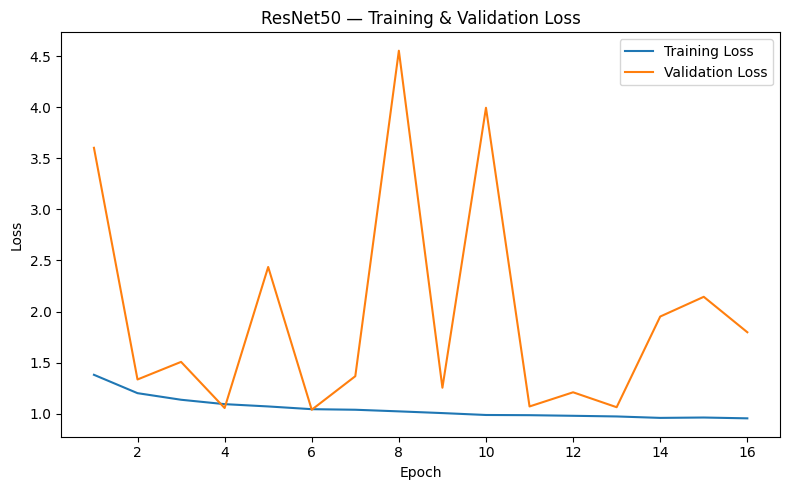

In [63]:
plot_loss(resnet50_history, 'ResNet50')


## ResNet101

In [64]:
resnet101 = build_transfer_model(ResNet101, 'resnet101')
display_added_layers(resnet101)

resnet101_history = resnet101.fit(
    X_train_aug, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)


171446536/171446536 [==============================] - 5s 0us/step
Model: resnet101
────────────────────────────────────────────────────────────────────
  Layer                            Output Shape               Params
════════════════════════════════════════════════════════════════════
  flatten_9                        (None, 32768)                   0
  dense_18                         (None, 64)               2,097,216
  batch_normalization_9            (None, 64)                    256
  dropout_9                        (None, 64)                      0
  dense_19                         (None, 6)                     390
────────────────────────────────────────────────────────────────────
  Trainable params:                                        2,097,862
Epoch 1/100


2026-05-31 15:47:48.618892: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - ETA: 0s - loss: 1.4649 - accuracy: 0.3942

2026-05-31 15:48:06.264354: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - 26s 63ms/step - loss: 1.4649 - accuracy: 0.3942 - val_loss: 4.5949 - val_accuracy: 0.1564
Epoch 2/100
351/351 [==============================] - 19s 55ms/step - loss: 1.2760 - accuracy: 0.4729 - val_loss: 1.1150 - val_accuracy: 0.5408
Epoch 3/100
351/351 [==============================] - 19s 55ms/step - loss: 1.2335 - accuracy: 0.4967 - val_loss: 1.0220 - val_accuracy: 0.5928
Epoch 4/100
351/351 [==============================] - 19s 55ms/step - loss: 1.1889 - accuracy: 0.5260 - val_loss: 0.9762 - val_accuracy: 0.6181
Epoch 5/100
351/351 [==============================] - 19s 54ms/step - loss: 1.1643 - accuracy: 0.5282 - val_loss: 1.6179 - val_accuracy: 0.4076
Epoch 6/100
351/351 [==============================] - 19s 55ms/step - loss: 1.1474 - accuracy: 0.5367 - val_loss: 1.2396 - val_accuracy: 0.5404
Epoch 7/100
351/351 [==============================] - 19s 55ms/step - loss: 1.1242 - accuracy: 0.5493 - val_loss: 2.5838 - val_accuracy: 0.32

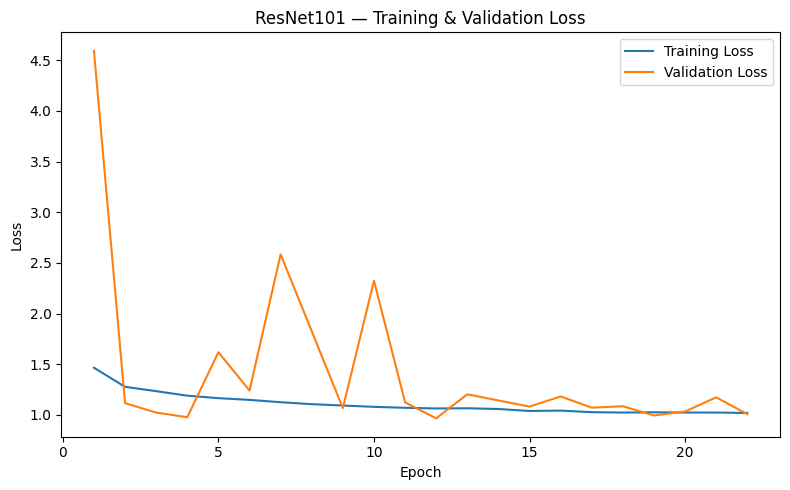

In [65]:
# plot ResNet101 training loss
plot_loss(resnet101_history, 'ResNet101')

## EfficientNetB0

In [66]:
efficientnet = build_transfer_model(EfficientNetB0, 'efficientnet')
display_added_layers(efficientnet)

efficientnet_history = efficientnet.fit(
    X_train_aug, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)


16705208/16705208 [==============================] - 1s 0us/step
Model: efficientnet
────────────────────────────────────────────────────────────────────
  Layer                            Output Shape               Params
════════════════════════════════════════════════════════════════════
  flatten_10                       (None, 20480)                   0
  dense_20                         (None, 64)               1,310,784
  batch_normalization_10           (None, 64)                    256
  dropout_10                       (None, 64)                      0
  dense_21                         (None, 6)                     390
────────────────────────────────────────────────────────────────────
  Trainable params:                                        1,311,430
Epoch 1/100


2026-05-31 15:56:04.237309: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - ETA: 0s - loss: 1.9522 - accuracy: 0.1829

2026-05-31 15:56:16.512282: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - 17s 35ms/step - loss: 1.9522 - accuracy: 0.1829 - val_loss: 1.9393 - val_accuracy: 0.1696
Epoch 2/100
351/351 [==============================] - 10s 28ms/step - loss: 1.8441 - accuracy: 0.2066 - val_loss: 2.5387 - val_accuracy: 0.1560
Epoch 3/100
351/351 [==============================] - 10s 28ms/step - loss: 1.8006 - accuracy: 0.2214 - val_loss: 3.2598 - val_accuracy: 0.1856
Epoch 4/100
351/351 [==============================] - 10s 29ms/step - loss: 1.7519 - accuracy: 0.2333 - val_loss: 1.8936 - val_accuracy: 0.1892
Epoch 5/100
351/351 [==============================] - 10s 29ms/step - loss: 1.7369 - accuracy: 0.2370 - val_loss: 1.6929 - val_accuracy: 0.2408
Epoch 6/100
351/351 [==============================] - 10s 28ms/step - loss: 1.7097 - accuracy: 0.2392 - val_loss: 3.3416 - val_accuracy: 0.1792
Epoch 7/100
351/351 [==============================] - 10s 28ms/step - loss: 1.6993 - accuracy: 0.2561 - val_loss: 2.4070 - val_accuracy: 0.18

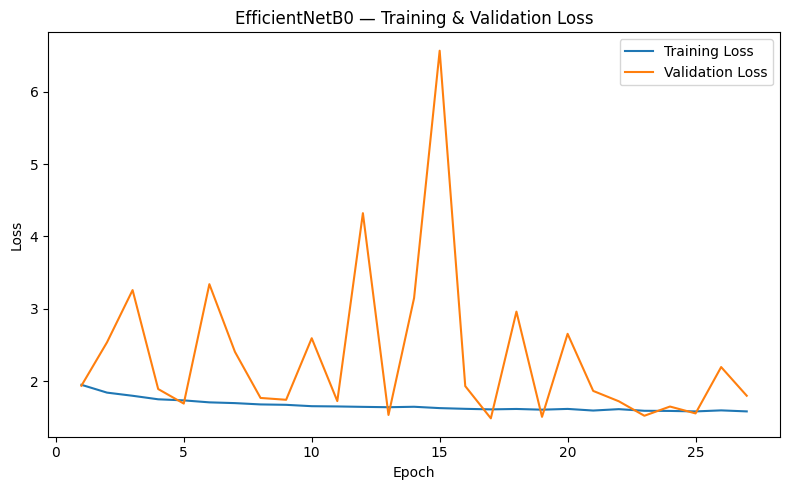

In [67]:
# plot EfficientNetB0 training loss
plot_loss(efficientnet_history, 'EfficientNetB0')

## VGG16

In [68]:
vgg16 = build_transfer_model(VGG16, 'vgg16')
display_added_layers(vgg16)

vgg16_history = vgg16.fit(
    X_train_aug, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)


58889256/58889256 [==============================] - 2s 0us/step
Model: vgg16
────────────────────────────────────────────────────────────────────
  Layer                            Output Shape               Params
════════════════════════════════════════════════════════════════════
  flatten_11                       (None, 8192)                    0
  dense_22                         (None, 64)                524,352
  batch_normalization_11           (None, 64)                    256
  dropout_11                       (None, 64)                      0
  dense_23                         (None, 6)                     390
────────────────────────────────────────────────────────────────────
  Trainable params:                                         524,998
Epoch 1/100


2026-05-31 16:01:11.167315: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - ETA: 0s - loss: 0.8671 - accuracy: 0.6703

2026-05-31 16:01:30.305353: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


351/351 [==============================] - 24s 66ms/step - loss: 0.8671 - accuracy: 0.6703 - val_loss: 0.4430 - val_accuracy: 0.8408
Epoch 2/100
351/351 [==============================] - 23s 64ms/step - loss: 0.6920 - accuracy: 0.7370 - val_loss: 0.4178 - val_accuracy: 0.8532
Epoch 3/100
351/351 [==============================] - 23s 64ms/step - loss: 0.6364 - accuracy: 0.7561 - val_loss: 0.4139 - val_accuracy: 0.8536
Epoch 4/100
351/351 [==============================] - 23s 65ms/step - loss: 0.5895 - accuracy: 0.7714 - val_loss: 0.4134 - val_accuracy: 0.8618
Epoch 5/100
351/351 [==============================] - 23s 66ms/step - loss: 0.5601 - accuracy: 0.7890 - val_loss: 0.4513 - val_accuracy: 0.8422
Epoch 6/100
351/351 [==============================] - 23s 67ms/step - loss: 0.5357 - accuracy: 0.7966 - val_loss: 0.4565 - val_accuracy: 0.8550
Epoch 7/100
351/351 [==============================] - 25s 70ms/step - loss: 0.5153 - accuracy: 0.8060 - val_loss: 0.5200 - val_accuracy: 0.83

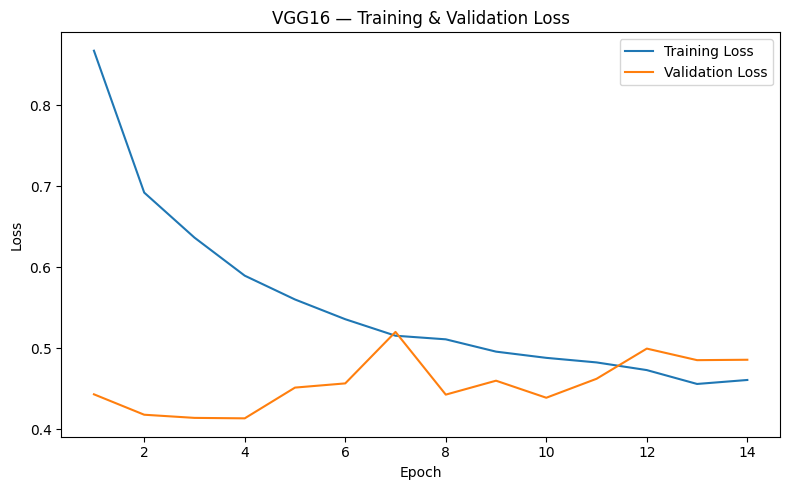

In [69]:
# plot VGG16 training loss
plot_loss(vgg16_history, 'VGG16')

# Evaluation

Predictions are computed for all four models on the training, validation, and test sets. The following sections display classification report DataFrames, ROC-AUC curves, and test-set confusion matrices for each model.

In [70]:
model_registry = [
    ('ResNet50',       resnet50),
    ('ResNet101',      resnet101),
    ('EfficientNetB0', efficientnet),
    ('VGG16',          vgg16),
]

predictions = {}
for model_name, model in model_registry:
    predictions[model_name] = {
        'train': model.predict(X_train_aug, verbose=0).astype(np.float32),
        'val':   model.predict(X_val,       verbose=0).astype(np.float32),
        'test':  model.predict(X_test,      verbose=0).astype(np.float32),
    }
print('Predictions computed.')


2026-05-31 16:11:36.134915: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-31 16:12:01.407494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-31 16:12:34.407970: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-31 16:12:48.698090: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Predictions computed.


## Classification Report DataFrames

For each model, a DataFrame is displayed for the training and test sets. The layout mirrors `classification_report` (precision, recall, F1-score, support per class, plus macro and weighted averages). Accuracy is reported separately as it does not span all columns.

In [73]:
def report_dataframe(y_true_cat, y_pred_proba):
    """Return a classification-report DataFrame with text class labels as index."""
    y_true = np.argmax(y_true_cat,   axis=1)
    y_pred = np.argmax(y_pred_proba, axis=1)

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        digits=3
    )
    accuracy = report.pop('accuracy')

    df = pd.DataFrame(report).T
    df[['precision', 'recall', 'f1-score']] = df[['precision', 'recall', 'f1-score']].round(3)
    df['support'] = df['support'].astype(int)
    return df, accuracy


splits = [
    ('Training',   y_train_cat, 'train'),
    ('Validation', y_val_cat,   'val'),
    ('Test',       y_test,      'test'),
]

for model_name, _ in model_registry:
    print(f'\n{"=" * 60}')
    print(f' {model_name}')
    print('=' * 60)

    for split_label, y_true_cat, split_key in splits:
        y_pred_proba = predictions[model_name][split_key]
        df, accuracy = report_dataframe(y_true_cat, y_pred_proba)

        print(f'\n{split_label} Set')
        ipy_display(df)
        print(f'Accuracy: {accuracy:.3f}')



 ResNet50

Training Set


,precision,recall,f1-score,support
buildings,0.517,0.714,0.600,1753
forest,0.440,0.971,0.605,1817
glacier,0.858,0.157,0.265,1923
mountain,0.571,0.553,0.561,2009
sea,0.615,0.495,0.549,1819
street,0.867,0.468,0.608,1906
macro avg,0.645,0.560,0.531,11227
weighted avg,0.648,0.554,0.530,11227


Accuracy: 0.554

Validation Set


,precision,recall,f1-score,support
buildings,0.508,0.820,0.627,438
forest,0.697,0.947,0.803,454
glacier,0.763,0.187,0.301,481
mountain,0.533,0.688,0.601,503
sea,0.628,0.567,0.596,455
street,0.826,0.529,0.645,476
macro avg,0.659,0.623,0.595,2807
weighted avg,0.660,0.618,0.593,2807


Accuracy: 0.618

Test Set


...

Accuracy: 0.806

Validation Set


,precision,recall,f1-score,support
buildings,0.896,0.847,0.871,438
forest,0.963,0.978,0.970,454
glacier,0.793,0.794,0.793,481
mountain,0.808,0.763,0.785,503
sea,0.878,0.870,0.874,455
street,0.844,0.929,0.884,476
macro avg,0.864,0.864,0.863,2807
weighted avg,0.862,0.862,0.861,2807


Accuracy: 0.862

Test Set


,precision,recall,f1-score,support
buildings,0.916,0.872,0.893,437
forest,0.969,0.983,0.976,474
glacier,0.823,0.781,0.801,553
mountain,0.811,0.785,0.798,525
sea,0.848,0.878,0.863,510
street,0.867,0.938,0.901,501
macro avg,0.872,0.873,0.872,3000
weighted avg,0.869,0.870,0.869,3000


Accuracy: 0.870


## ROC-AUC Curves

ROC curves are plotted per class (one-vs-rest) for the training and test sets of each model. The overall AUC score (macro OvR) is shown in each subplot title.

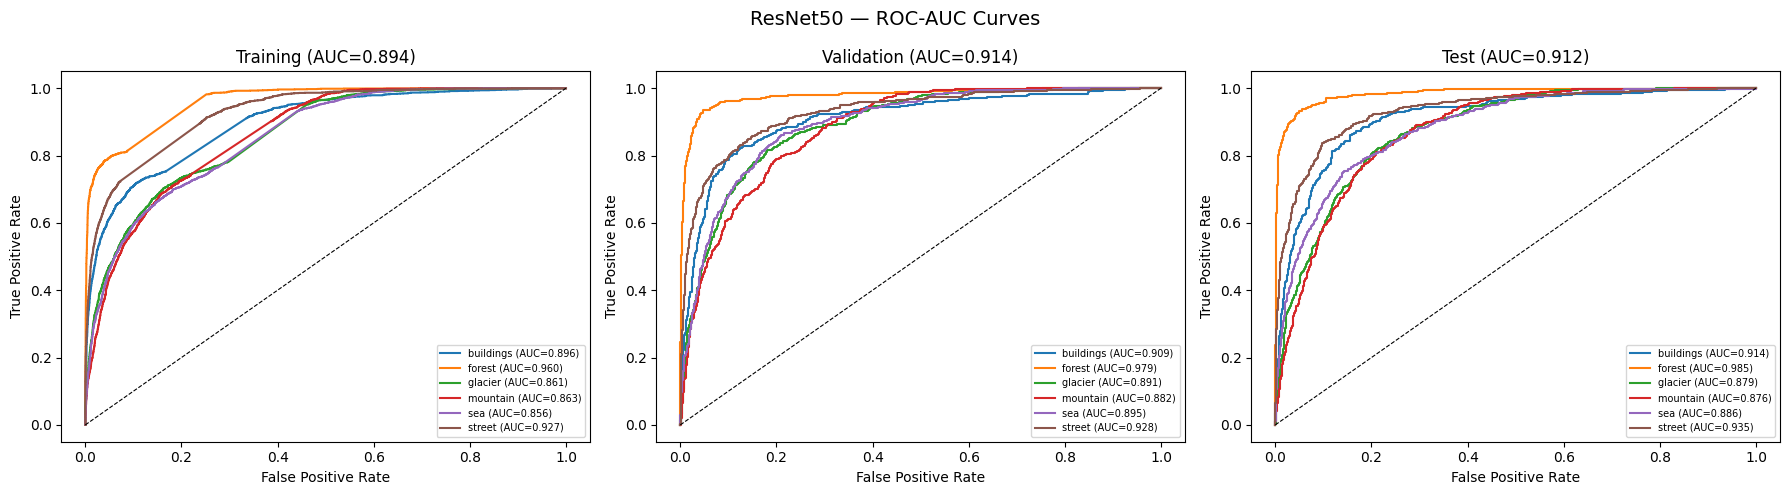

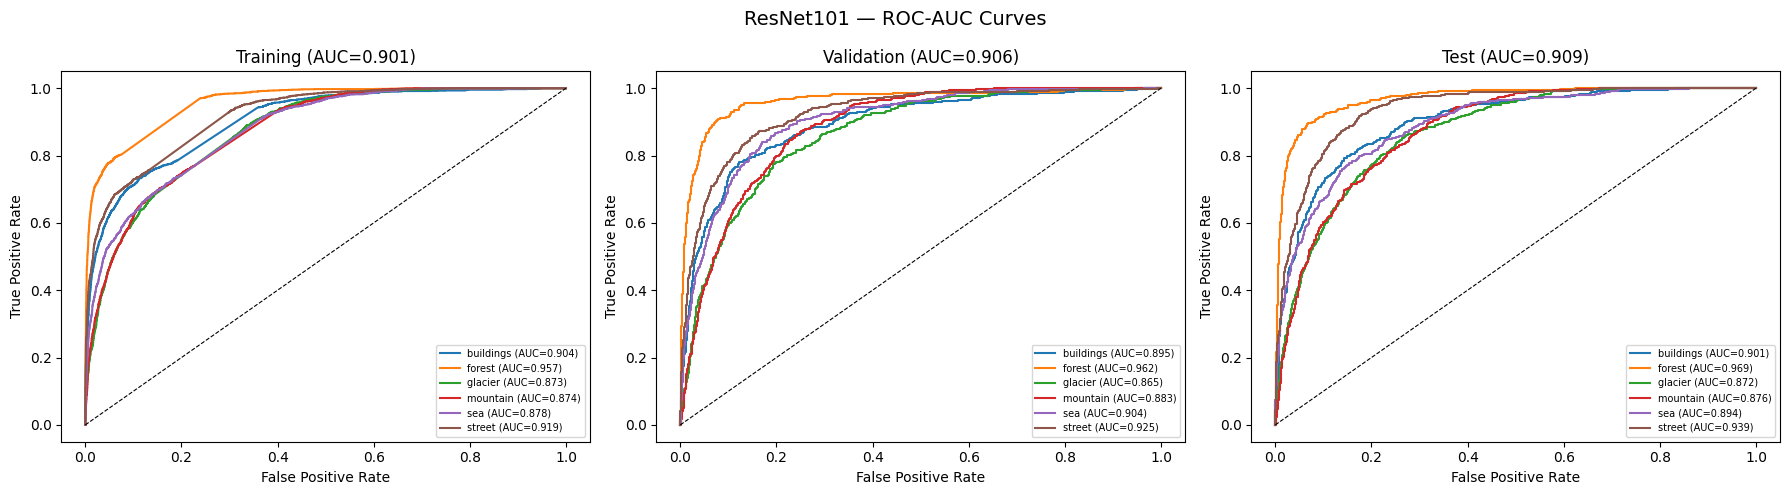

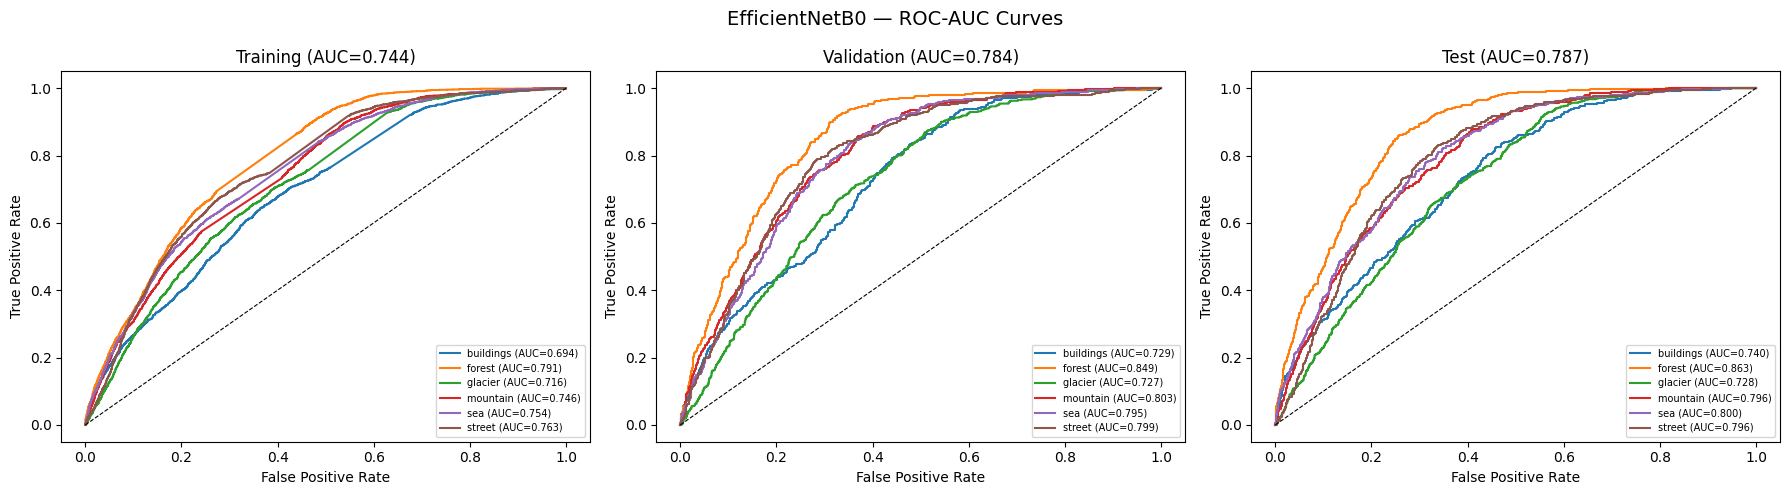

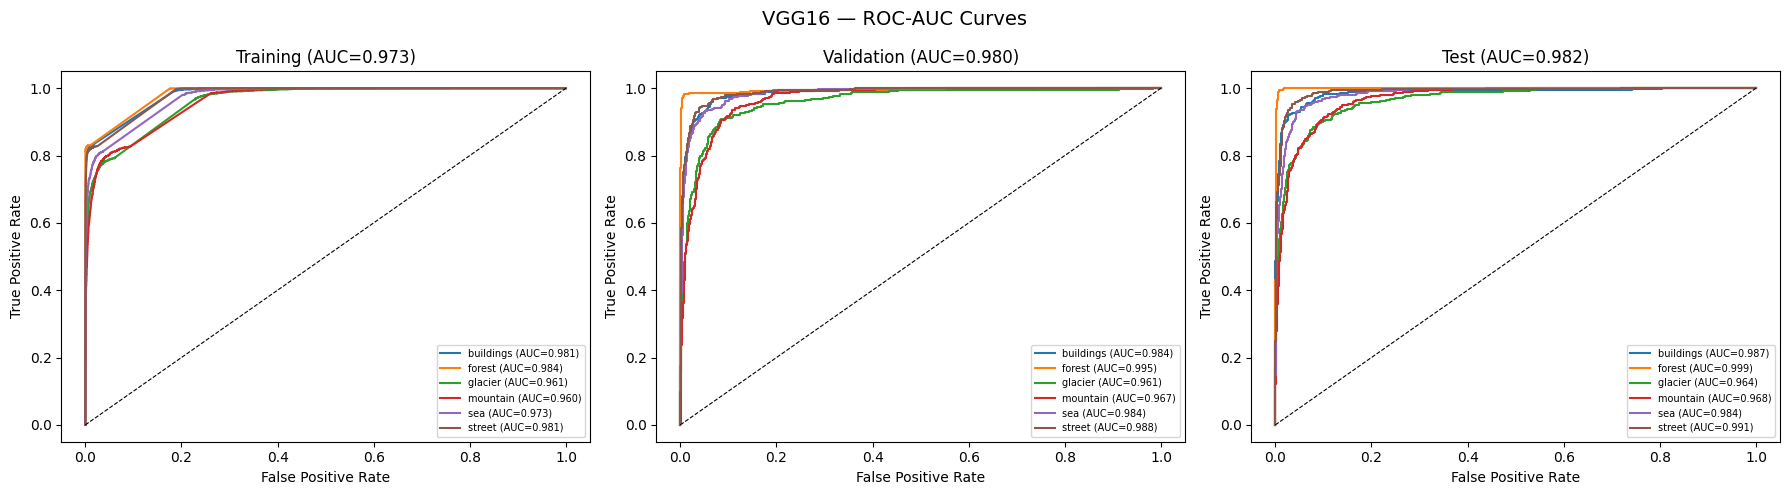

In [74]:
for model_name, _ in model_registry:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} \u2014 ROC-AUC Curves', fontsize=14)

    for ax, (split_label, y_true_cat, split_key) in zip(axes, splits):
        y_pred_proba = predictions[model_name][split_key]
        overall_auc  = roc_auc_score(y_true_cat, y_pred_proba, multi_class='ovr')

        for i, class_name in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(y_true_cat[:, i], y_pred_proba[:, i])
            class_auc   = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{class_name} (AUC={class_auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
        ax.set_title(f'{split_label} (AUC={overall_auc:.3f})')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower right', fontsize=7)

    plt.tight_layout()
    plt.show()


## Confusion Matrices

Test-set confusion matrices are displayed for each model with class names as axis labels.

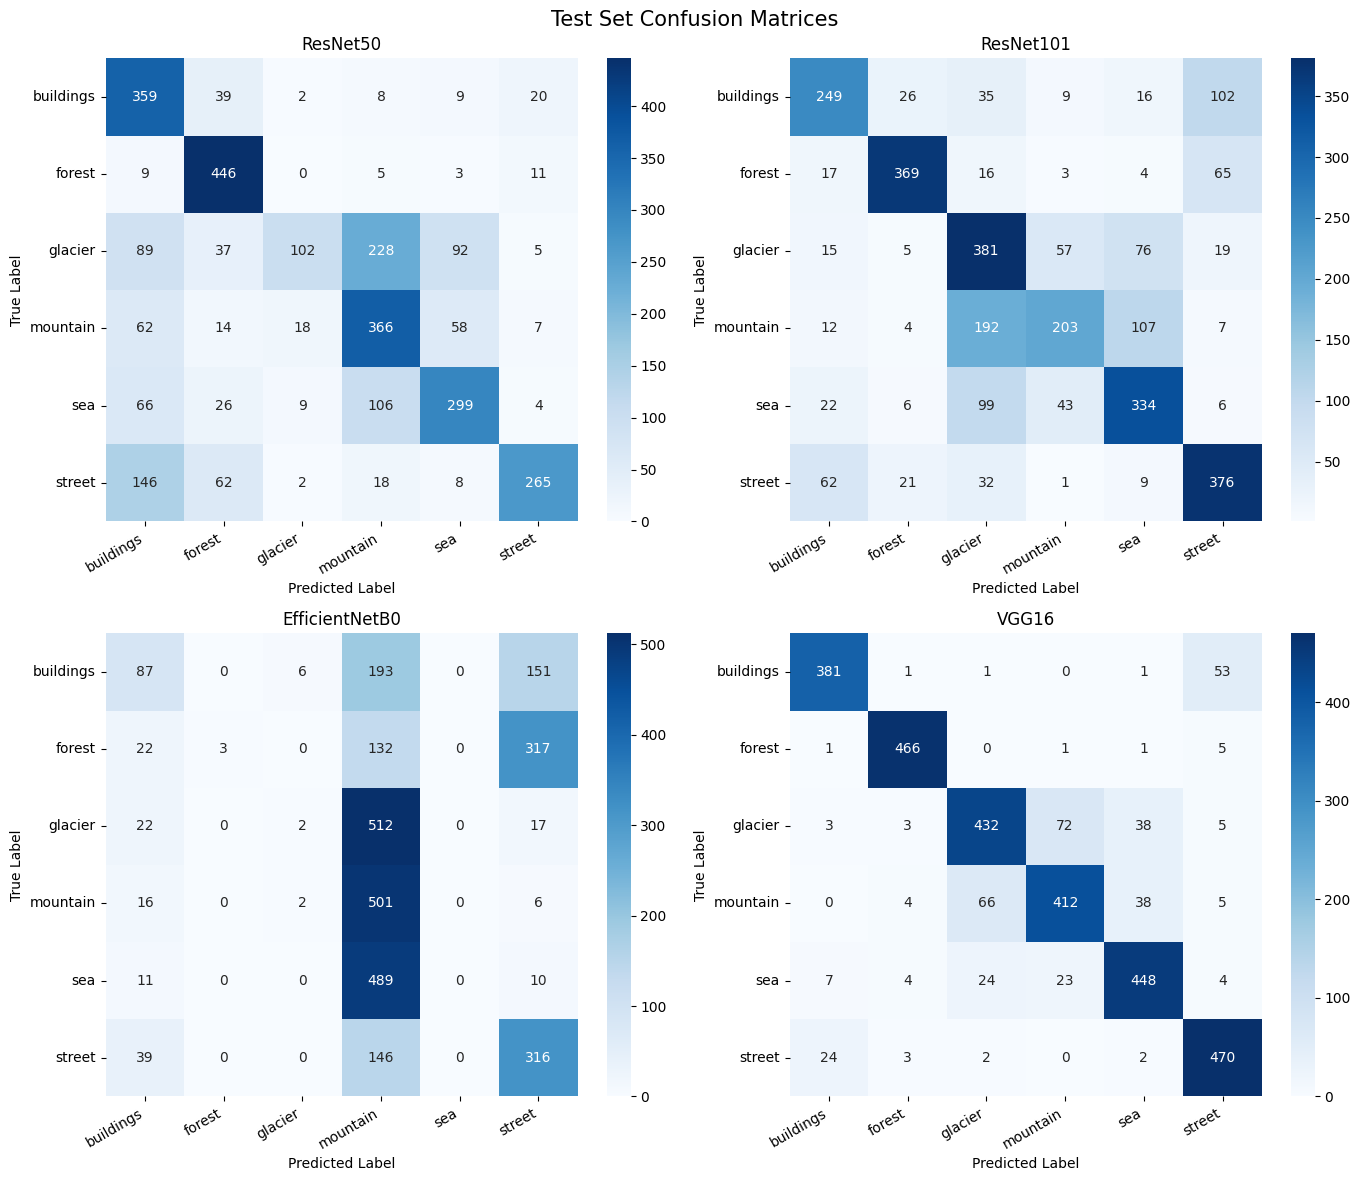

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Test Set Confusion Matrices', fontsize=15)

for ax, (model_name, _) in zip(axes.flat, model_registry):
    y_pred = np.argmax(predictions[model_name]['test'], axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues'
    )
    ax.set_title(f'{model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()